In [ ]:
# Install packages
!pip -q install PyTDC rdkit shap tqdm matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.9.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.9.0 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
imbalanced-learn 0.14.0 requires scikit-learn<2,>=1.4.2, but you have scikit-learn 1.2.2 which is incompatible.
mlxtend 0.23.4 requires scikit-learn>=1.3.1, but you have scikit-learn 1.2.2 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cuml-cu12 25.6.0 re

In [ ]:
# Import necessary libraries
from tdc.single_pred import ADME
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow import keras
from sklearn.metrics import accuracy_score, roc_auc_score

# set random seed for reproducibility
np.random.seed (2)
tf.random.set_seed(2)

# Data Prepartion

In [ ]:
# === Load dataset (ignore predefined splits) ===
data = ADME(name="HIA_Hou")
df_adme = data.get_data()  # get the full dataset directly

# Standardize column name
df_adme = df_adme.rename(columns={"Drug": "smiles"})

print (df_adme)

Downloading...
100%|██████████| 40.1k/40.1k [00:00<00:00, 1.98MiB/s]
Loading...
Done!


               Drug_ID                                             smiles  Y
0          Acetanilide                                    CC(=O)Nc1ccccc1  1
1    Acetazolamide.mol                         CC(=O)Nc1nnc(S(N)(=O)=O)s1  1
2         Alfacalcidol  C=C1/C(=C\C=C2/CCC[C@]3(C)[C@@H]2CC[C@H]3[C@@H...  1
3          Aminopyrine                    Cc1c(N(C)C)c(=N)n(-c2ccccc2)n1C  1
4       Amosulalol.mol      COc1ccccc1OCCNC[C@@H](O)c1ccc(C)cc1S(N)(=O)=O  1
..                 ...                                                ... ..
573    Tiludronic_acid                 O=P(O)(O)C(Cc1ccc(Cl)cc1)P(=O)(O)O  0
574      Zanamivir.mol  CC(=O)N[C@H]1[C@@H]([C@@H](O)[C@H](O)CO)OC(C(=...  0
575      Kanamycin.mol  CC(=O)NC[C@@H]1O[C@@H](O[C@H]2[C@@H](N)C[C@H](...  0
576       Amikacin.mol  NCC[C@@H](O)C(=O)N[C@@H]1C[C@H](N)[C@H](O[C@@H...  0
577     Moxalactam.mol  CO[C@@]1(NC(=O)[C@@H](C(=O)O)c2ccc(O)cc2)C(=O)...  0

[578 rows x 3 columns]


In [ ]:
# === Convert SMILES strings into MACCS fingerprints ===
# MACCS keys are 166-bit structural fingerprints (plus 1 indexing offset)
# capturing the presence/absence of predefined substructures in a molecule.

from rdkit import Chem, DataStructs
from rdkit.Chem import MACCSkeys
import numpy as np

def smiles_to_maccs(smiles):
    # Convert SMILES string to an RDKit molecule object
    mol = Chem.MolFromSmiles(smiles)

    # If SMILES cannot be parsed (invalid structure), return a zero vector
    if mol is None:
        return np.zeros(167)

    # Generate MACCS structural keys fingerprint for the molecule
    fp = MACCSkeys.GenMACCSKeys(mol)

    # Convert RDKit fingerprint object into a NumPy array (float32)
    arr = np.zeros((167,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)

    # Return the binary vector (each bit = a substructure feature)
    return arr

In [ ]:
# Apply the fingerprint conversion function to each molecule
df_adme["MACCS"] = df_adme["smiles"].apply(smiles_to_maccs)

# Display the updated dataset
df_adme

,Drug_ID,smiles,Y,MACCS
0,Acetanilide,CC(=O)Nc1ccccc1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,Acetazolamide.mol,CC(=O)Nc1nnc(S(N)(=O)=O)s1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,Alfacalcidol,C=C1/C(=C\C=C2/CCC[C@]3(C)[C@@H]2CC[C@H]3[C@@H...,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,Aminopyrine,Cc1c(N(C)C)c(=N)n(-c2ccccc2)n1C,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,Amosulalol.mol,COc1ccccc1OCCNC[C@@H](O)c1ccc(C)cc1S(N)(=O)=O,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...,...
573,Tiludronic_acid,O=P(O)(O)C(Cc1ccc(Cl)cc1)P(=O)(O)O,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
574,Zanamivir.mol,CC(=O)N[C@H]1[C@@H]([C@@H](O)[C@H](O)CO)OC(C(=...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
575,Kanamycin.mol,CC(=O)NC[C@@H]1O[C@@H](O[C@H]2[C@@H](N)C[C@H](...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
576,Amikacin.mol,NCC[C@@H](O)C(=O)N[C@@H]1C[C@H](N)[C@H](O[C@@H...,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [ ]:
# Stratified Data Splitting for Model Training and Evaluation ===
from sklearn.model_selection import train_test_split

# Split the full dataset into training (80%) and test (20%) sets
train_df, test_df = train_test_split(
    df_adme,
    test_size=0.2,                 # 20% of data reserved for testing
    stratify=df_adme["Y"],         # maintain class balance (0/1 ratio)
    random_state=42                # ensures reproducibility
)

In [ ]:
# Extract feature matrices (X) and target vectors (y)
X_train = np.vstack(train_df["MACCS"].values)
y_train = train_df["Y"].values

X_test = np.vstack(test_df["MACCS"].values)
y_test = test_df["Y"].values

In [ ]:
# Create an internal validation set from the training data
# This helps during model development (e.g., hyperparameter tuning)
X_train_main, X_val, y_train_main, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

In [ ]:
# Import required modules from Keras (TensorFlow backend)
from keras.models import Sequential           # Linear stack of layers
from keras.layers import Dense, Dropout       # Fully-connected & dropout layers
from keras.optimizers import Adam             # Optimizer for gradient descent

# Define model architecture
model = Sequential([
    # Input layer → first hidden layer with 512 neurons
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.4),                             # randomly drop 40% neurons (prevent overfitting)

    # Second hidden layer with 256 neurons
    Dense(256, activation='relu'),
    Dropout(0.3),                             # drop 30% neurons

    # Output layer: one neuron (binary classification)
    Dense(1, activation='sigmoid')            # sigmoid outputs probability (0–1)
])

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=1e-4),       # Adam optimizer with small learning rate
    loss='binary_crossentropy',               # binary loss for 0/1 labels
    metrics=['accuracy', keras.metrics.AUC(name='auc')]  # track accuracy and AUC during training
)

In [ ]:
# Some ADME datasets (like HIA_Hou) may have more 'well absorbed' (1)
# than 'poorly absorbed' (0) compounds → class imbalance problem.
# To correct this, we assign higher weights to minority samples.

from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',        # automatically balances class frequencies
    classes=np.unique(y_train),     # list of unique labels (0, 1)
    y=y_train                       # target array
)

class_weights = dict(enumerate(class_weights))  # convert to dictionary form

In [ ]:
# Add Early Stopping to prevent overfitting during training
from keras.callbacks import EarlyStopping

es = EarlyStopping(
    monitor='val_auc',              # monitor validation AUC
    patience=10,                    # stop if no improvement for 10 epochs
    restore_best_weights=True,      # keep best model weights
    mode='max'                      # higher AUC = better
)

# Train the model
hist = model.fit(
    X_train_main, y_train_main,      # training data
    validation_data=(X_val, y_val),  # use validation set for monitoring
    class_weight=class_weights,      # apply class weighting
    epochs=20,                       # max number of epochs
    batch_size=64,                   # number of samples per gradient update
    callbacks=[es],                  # use EarlyStopping
    verbose=0                        # silent training output
)

## Step 9: Evaluate Model Performance on Test Data

In [ ]:
# Predict probabilities for test samples
y_pred_prob = model.predict(X_test).squeeze()

# Convert probabilities into binary class predictions
y_pred = (y_pred_prob >= 0.5).astype(int)

# Compute evaluation metrics
acc = accuracy_score(y_test, y_pred)           # overall classification accuracy
auc = roc_auc_score(y_test, y_pred_prob)       # area under the ROC curve

# Display performance results
print(f"\nTest Accuracy: {acc:.3f}")
print(f"Test AUC:      {auc:.3f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Test Accuracy: 0.897
Test AUC:      0.909


In [ ]:
!pip -q install shap matplotlib seaborn


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap

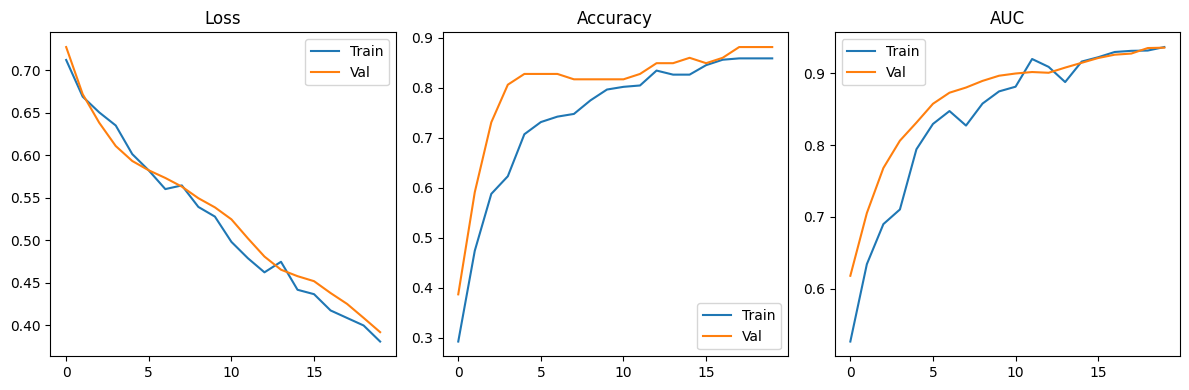

In [ ]:
def plot_training_curves(hist):
    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 3, 1)
    plt.plot(hist.history['loss'], label='Train')
    plt.plot(hist.history.get('val_loss', []), label='Val')
    plt.title('Loss')
    plt.legend()

    # Accuracy
    if 'accuracy' in hist.history:
        plt.subplot(1, 3, 2)
        plt.plot(hist.history['accuracy'], label='Train')
        plt.plot(hist.history.get('val_accuracy', []), label='Val')
        plt.title('Accuracy')
        plt.legend()

    # AUC
    if 'auc' in hist.history:
        plt.subplot(1, 3, 3)
        plt.plot(hist.history['auc'], label='Train')
        plt.plot(hist.history.get('val_auc', []), label='Val')
        plt.title('AUC')
        plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curves(hist)

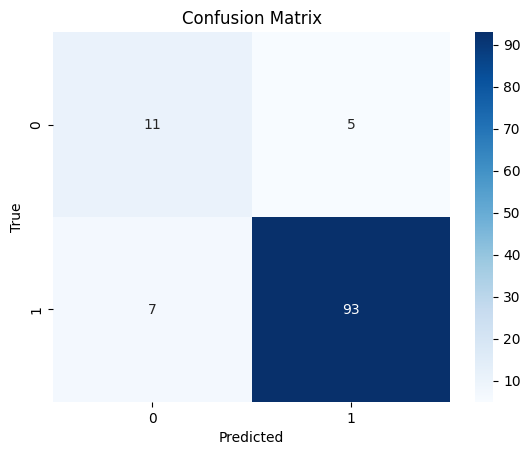

In [ ]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred)


In [ ]:
# Manual MACCS key label mapping (bit_001 → functional group)
maccs_manual_mapping = {
    f"bit_{i:03d}": name for i, name in enumerate([
        "Any Atom", "Hydrogen", "T1", "T2", "T3", "T4", "T5", "T6",
        "N+Q", "CH3X", "OH", "COOH", "NH2", "NO2", "CH3", "CH2",
        "CH", "C", "N", "O", "F", "Cl", "Br", "I", "P", "S",
        "CN", "NC", "CO", "OC", "CC", "CS", "SC", "NH", "NH2",
        "NHR", "NR2", "NO", "N=O", "NHCO", "CNH", "C=O", "COC",
        "COOH", "CONH", "COOR", "C=N", "CNH2", "C=N-O", "O=C-NH",
        "OH (alcohol)", "OH (phenol)", "C=C", "C#C", "C=C-C=C",
        "Aromatic ring", "Hetero aromatic", "3-ring", "4-ring",
        "5-ring", "6-ring", "Fused rings", "Bridgehead C",
        "Carbon chain", "Branched chain", "Alkene chain",
        "C-C", "C=C", "C#C", "C-C-C", "C-C=C", "C=C-C",
        "C-C#C", "C-C-N", "C-C-O", "C-C-S", "C-C-Cl", "C-C-Br",
        "C-C-I", "C-C-F", "N-N", "N-O", "N=S", "N=C=O",
        "N=C-N", "N-C=O", "S-S", "S=O", "SO2", "Ring CH2",
        "O-C=O", "C-O-C", "C-N-C", "C=C-C", "C=C-O", "C=C-N",
        "C=C-C=C", "C=C-C-C", "Aromatic-N", "Aromatic-O",
        "3-membered ring", "4-membered ring", "5-membered ring",
        "Sulfonamide", "Halogen", "Heteroatom", "Charge",
        "Isotope", "Donor", "Acceptor", "H-bond", "Hydrophobe",
        "Acidic", "Basic", "Metal", "Aliphatic chain",
        "Amide", "Thiol", "Thioether", "Ester", "Ether",
        "Imine", "Phenol", "Ketone", "Urea", "Tertiary amine",
        "Aromatic ring with N", "Amine", "Alcohol", "Lactam",
        "Lactone", "Hydrazine", "Imidazole", "Pyridine",
        "Tetrazole", "Triazole", "Oxazole", "Isoxazole",
        "Oxadiazole", "Sulfoxide", "Sulfur ring", "Phosphonate",
        "Nitrate", "Nitro", "Azide", "Isocyanate", "Misc."
    ] + [f"Unlabeled_{i}" for i in range(148, 167)], start=0)
}

PermutationExplainer explainer: 117it [00:26,  2.98it/s]


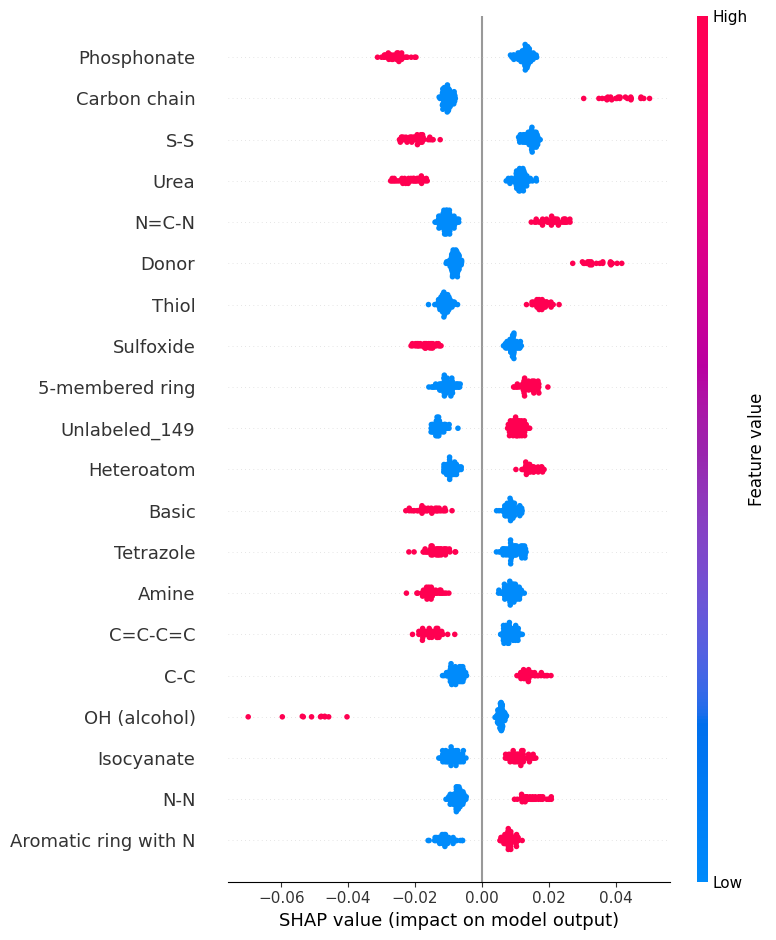

In [ ]:
# SHAP (SHapley Additive exPlanations) helps explain how each molecular feature
# (MACCS bit) contributes to the model’s prediction of absorption probability.

# Create SHAP explainer
explainer = shap.Explainer(model, X_test, algorithm="auto")

# Compute SHAP values for the test set
shap_values = explainer(X_test)

# Rename feature names for interpretability
feature_names = [f"bit_{i:03d}" for i in range(1, 167)]            # 167 MACCS bits
renamed_features = [maccs_manual_mapping.get(f, f) for f in feature_names]
# (Optional) 'maccs_manual_mapping' translates bit IDs into substructure names
# e.g., bit_001 → "Hydroxyl group", bit_002 → "Aromatic ring"

# Generate summary plot
shap.summary_plot(shap_values, X_test, feature_names=renamed_features, plot_type="dot")